In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from equivariant_diffusion.en_diffusion import LearnedAdaptiveNoiseSchedule
from configs.datasets_config import qm9_with_h, geom_with_h

In [10]:
NUM_STEPS = 1000
PRECISION = 1e-4          
POLY_POWER = 2.0          
SCALED_POLY_POWER = 2.0
DEVICE = "cpu"

In [11]:
def extract_gamma_state_dict(ckpt_path: str):
    """Return only the gamma.* weights (prefix stripped) from a checkpoint saved as an OrderedDict."""
    sd = torch.load(ckpt_path, map_location="cpu")
    gamma_sd = {k[len("gamma."):]: v for k, v in sd.items() if k.startswith("gamma.")}
    if not gamma_sd:
        raise RuntimeError(f"No 'gamma.*' keys found in checkpoint: {ckpt_path}")
    return gamma_sd

def build_schedule_learned(input_dim: int, gamma_sd: dict, LearnedAdaptiveNoiseScheduleCls):
    """Instantiate the learned schedule and load weights."""
    model = LearnedAdaptiveNoiseScheduleCls(dataset_info=None, noise_context=None, input_dim=input_dim)
    model.load_state_dict(gamma_sd, strict=True)
    model.eval()
    return model

def gamma_to_curves(gamma: torch.Tensor):
    """
    Convert γ(t) to α(t), σ(t), SNR(t), logSNR(t) using the common log-SNR parameterization:
      σ² = sigmoid(γ), α² = sigmoid(−γ) = 1 − sigmoid(γ), SNR = exp(−γ), logSNR = −γ
    """
    sigma2 = torch.sigmoid(gamma)
    alpha2 = torch.sigmoid(-gamma)
    alpha = torch.sqrt(alpha2)
    sigma = torch.sqrt(sigma2)
    snr = torch.exp(-gamma)
    log_snr = -gamma
    return alpha, sigma, snr, log_snr

In [12]:
def main():
    # x-axis (1..T)
    timesteps = torch.arange(1, NUM_STEPS + 1, dtype=torch.float32, device=DEVICE)
    t_norm = (timesteps / NUM_STEPS).unsqueeze(1)  # [T,1]

    all_series = []  # list of dicts: {label, alpha, sigma, snr, log_snr, gamma}

    # --- LEARNED RUNS ---
    C_VALUE = 92.0
    RUNS = [
    {"path": "outputs/drugs_learned_adaptive_resume/generative_model.npy", "label": "drugs", "input_dim": 1},
    ]
    
    for run in RUNS:
        gamma_sd = extract_gamma_state_dict(run["path"])
        schedule = build_schedule_learned(run["input_dim"], gamma_sd, LearnedAdaptiveNoiseSchedule).to(DEVICE)
        c = torch.full((NUM_STEPS, run["input_dim"]), float(C_VALUE), device=DEVICE)

        with torch.no_grad():
            gamma = schedule(t_norm, c).squeeze(-1)

        alpha, sigma, snr, log_snr = gamma_to_curves(gamma)
        all_series.append({
            "label": run["label"], "alpha": alpha.cpu(), "sigma": sigma.cpu(),
            "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma.cpu()
    })
        
    # --- 3 LEARNED RUNS ---

    C_VALUE = 16.0

    RUNS = [
        {"path": "outputs/qm9_learned_adaptive/generative_model.npy", "label": "qm9", "input_dim": 1},
    ]
    
    for run in RUNS:
        gamma_sd = extract_gamma_state_dict(run["path"])
        schedule = build_schedule_learned(run["input_dim"], gamma_sd, LearnedAdaptiveNoiseSchedule).to(DEVICE)
        c = torch.full((NUM_STEPS, run["input_dim"]), float(C_VALUE), device=DEVICE)

        with torch.no_grad():
            gamma = schedule(t_norm, c).squeeze(-1)

        alpha, sigma, snr, log_snr = gamma_to_curves(gamma)
        all_series.append({
            "label": run["label"], "alpha": alpha.cpu(), "sigma": sigma.cpu(),
            "snr": snr.cpu(), "log_snr": log_snr.cpu(), "gamma": gamma.cpu()
    })    

    # ------------------------------------------------------
    # PLOTS: α, σ, SNR, log-SNR, γ
    # ------------------------------------------------------
    x = np.arange(1, NUM_STEPS + 1)

    def plot_metric(y_key, title, ylabel, yscale=None):
        plt.figure(figsize=(10, 6))
        for series in all_series:
            plt.plot(x, series[y_key], label=series["label"], linewidth=2)
        plt.title(title, fontsize=16)
        plt.xlabel("Timestep", fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        if yscale:
            plt.yscale(yscale)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    # α(t)
    plot_metric("alpha", r"$\alpha(t)$", r"$\alpha$")

    # σ(t)
    plot_metric("sigma", r"$\sigma(t)$", r"$\sigma$")

    # SNR(t) – log scale for clarity
    plot_metric("snr", "SNR(t)", "SNR", yscale="log")

    # log-SNR(t)
    plot_metric("log_snr", "log-SNR(t)", "log-SNR")

    # γ(t)
    plot_metric("gamma", r"$\gamma(t)$", r"$\gamma$")


### Comparasion of schedulers between datasets

Noise Schedule class: LearnedAdaptiveNoiseSchedule
  - dataset_info: None
  - noise_context: None
  - input_dim: 1
  - __class__: <class 'equivariant_diffusion.en_diffusion.LearnedAdaptiveNoiseSchedule'>
Noise Schedule class: LearnedAdaptiveNoiseSchedule
  - dataset_info: None
  - noise_context: None
  - input_dim: 1
  - __class__: <class 'equivariant_diffusion.en_diffusion.LearnedAdaptiveNoiseSchedule'>


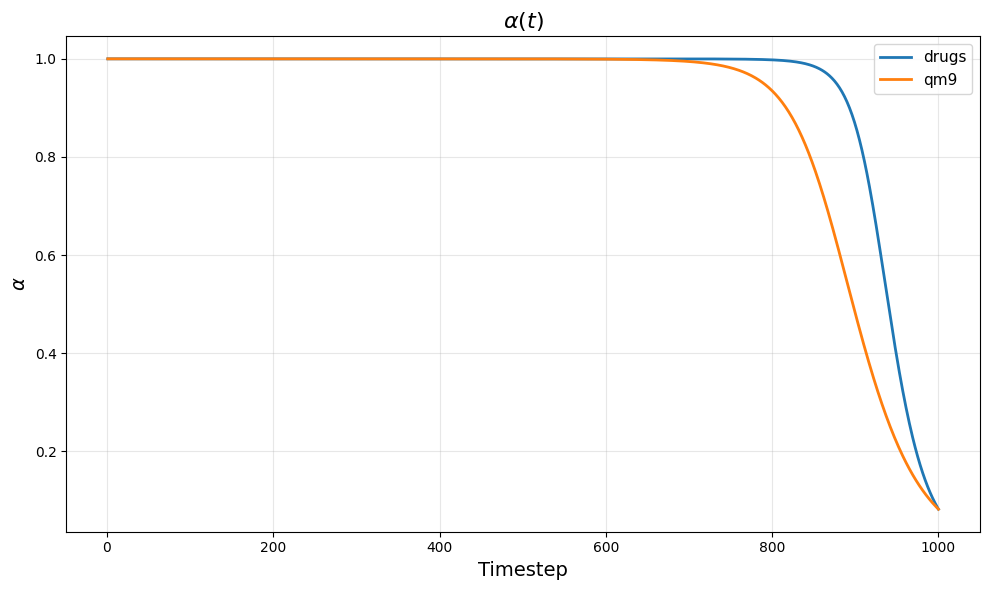

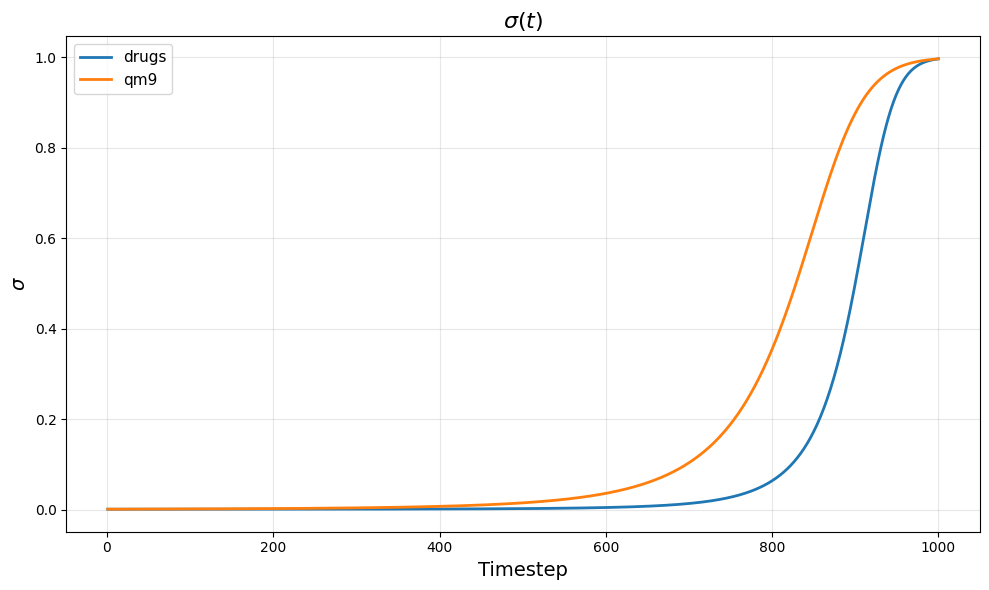

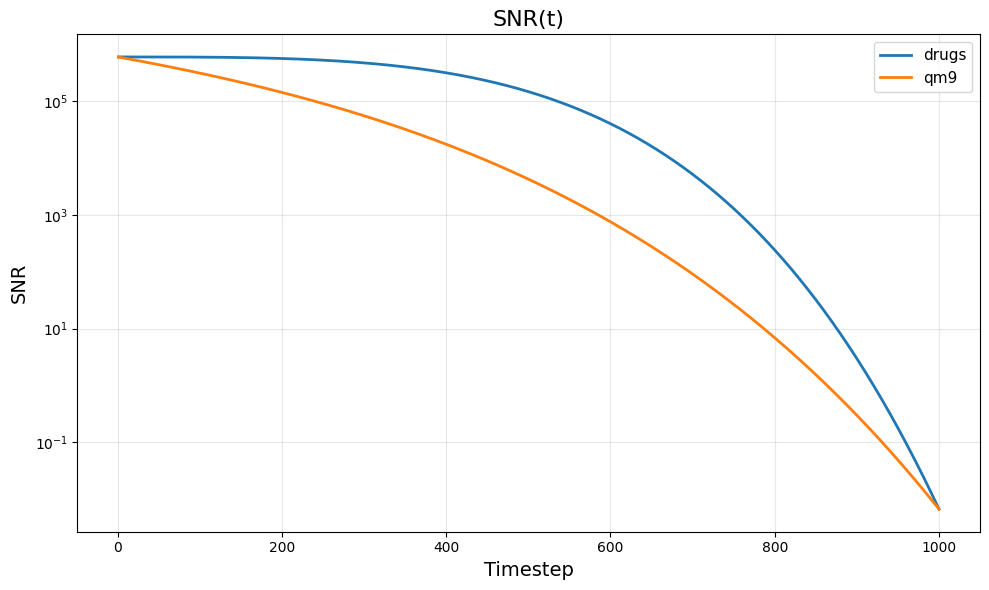

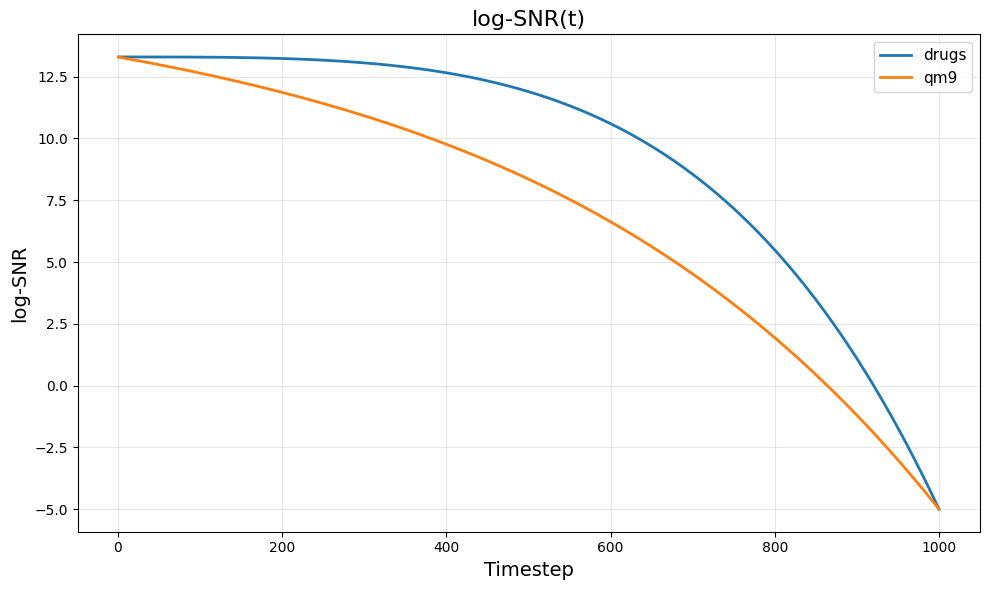

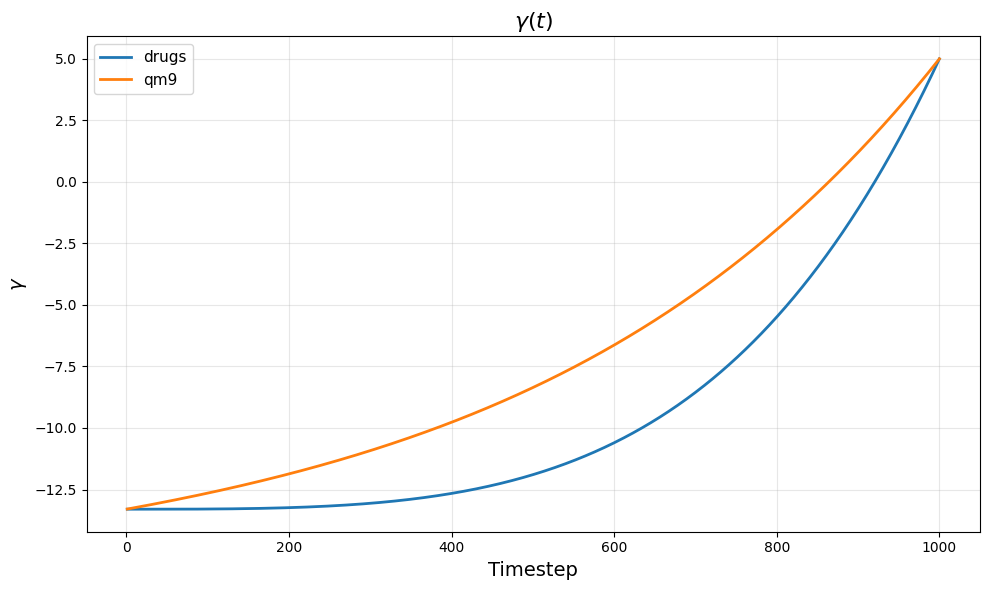

In [13]:
if __name__ == "__main__":
    main()